## 

In [62]:
import pandas as pd

In [63]:
fruits = pd.read_csv("../Data/fruits.csv")
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


### Feature Set과 Target Set를 Numpy Array로 변경

In [64]:
import numpy as np

----
#### 연습

In [65]:
# numpy의 column stack과 row stack
testA = np.array([1,2,3,4])
testB = np.array([10,20,30,40])

# 2개의 Array를 묶어서 컬럼기반 Array로 만들기
combineA = [[i,j]for i,j in zip(testA, testB)]
print(np.array(combineA))
print("-" * 50)

# numpy에서 컬럼 기반 
combineB = np.column_stack((testA, testB))
print(combineB)
print("-" * 50)

# numpy에서 Data 
combineD = np.hstack((testA, testB))
print(combineD)
print("-" * 50)

# numpy에서 index 기반
combineC = np.vstack((testA,testB))
print(combineC)
print("-" * 50)

[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
--------------------------------------------------
[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
--------------------------------------------------
[ 1  2  3  4 10 20 30 40]
--------------------------------------------------
[[ 1  2  3  4]
 [10 20 30 40]]
--------------------------------------------------


In [66]:
# List Comperhension
test1 = []

# 1)
for i in range(1,10+1):
   test1.append(i)

# 2) 1번의 내용과 동일하게 적은 것
test1 = [i for i in range (1,10+1) if i%2 == 0]
test1

[2, 4, 6, 8, 10]

In [67]:
# fruits와 feature
fruits_data = np.column_stack((fruits.length, fruits.weight))
fruits_data[:5]

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

In [68]:
fruits_data.shape

(49, 2)

In [69]:
# Target
fruits_target = np.array(fruits.name)
fruits_target[:5]


array(['apple', 'apple', 'apple', 'apple', 'apple'], dtype=object)

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
train_input, test_input, train_target, test_target = \
train_test_split(
   fruits_data,
   fruits_target,
   random_state=42,
   stratify=fruits_target # target의 비율을 검토해서 추출
)

In [72]:
# kNN을 이용한 예측
from sklearn.neighbors import KNeighborsClassifier

In [73]:
# Model 만들기
kn = KNeighborsClassifier() # n_neighobors=5

# 학습시키기
kn.fit(train_input,train_target)

# 검증하기
print(kn.score(train_input,train_target))
print(kn.score(test_input,test_target))

1.0
1.0


----
#### 수상한 과일

In [74]:
# length가 25cm이고 weight가 150g인 과일은?

kn.predict([[25,150]])

array(['berry'], dtype=object)

#### 시각화

In [75]:
import matplotlib.pyplot as plt

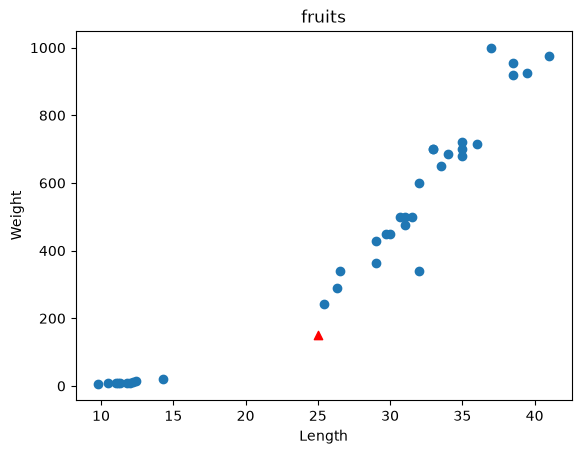

In [76]:
plt.scatter(
   train_input[:,0],
   train_input[:,1]
)

plt.scatter(
   25,
   150,
   marker="^",
   c="red"
)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('fruits')
plt.show()

#### 이웃 출력

In [77]:
distances, indexes = kn.kneighbors([[25,150]])

print(indexes)

[[11 20 13 22 15]]


In [78]:
# 이웃 index에 해당하는 Feature을 출력
train_input[indexes]

array([[[ 25.4, 242. ],
        [ 14.3,  19.7],
        [ 12.4,  13.4],
        [ 12.2,  12.2],
        [ 26.3, 290. ]]])

In [79]:
# 이웃 index에 해당하는 Target을 출력
train_target[indexes]

array([['apple', 'berry', 'berry', 'berry', 'apple']], dtype=object)

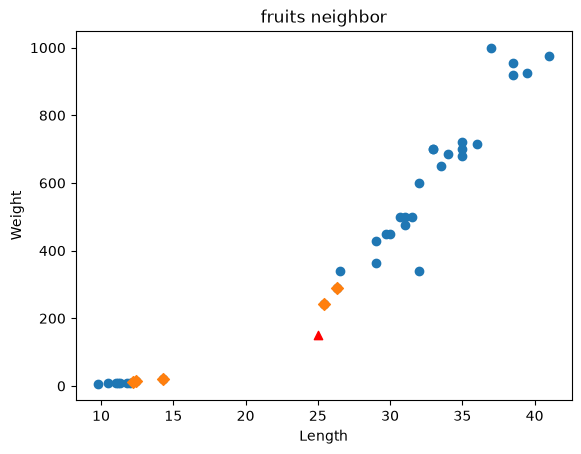

In [80]:
# 이웃의 위치를 출력
plt.scatter(
   train_input[:,0],
   train_input[:,1]
)

plt.scatter(
   25,
   150,
   marker="^",
   c="red"
)

plt.scatter(
   train_input[indexes,0],
   train_input[indexes,1],
   marker='D'
)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('fruits neighbor')
plt.show()

----
#### 기준을 맞추자
x축과 y축의 수치

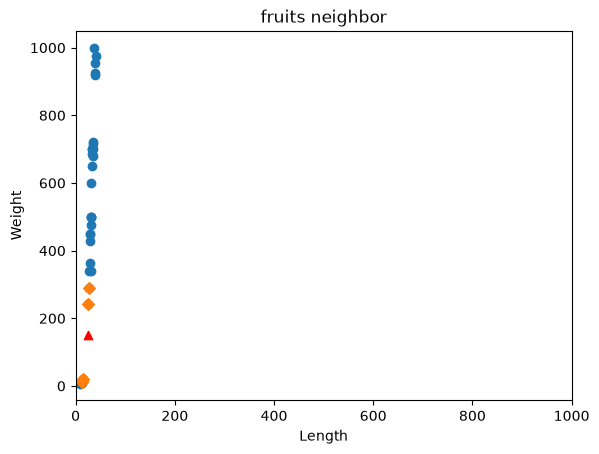

In [81]:
# 이웃의 위치를 출력
plt.scatter(
   train_input[:,0],
   train_input[:,1]
)

plt.scatter(
   25,
   150,
   marker="^",
   c="red"
)

plt.scatter(
   train_input[indexes,0],
   train_input[indexes,1],
   marker='D'
)

plt.xlim(0,1000)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('fruits neighbor')
plt.show()

> data가 Length에는 거의 영향을 받지 않고 weight에서 영향을 많이 받는다. 중요한 Feature는 Weight

In [82]:
# Length와 Weigth의 평균과 표준편차 
mean = np.mean(train_input, axis=0) # shape를 찍어보면 알 수 있음. (데이터 차원에 따라 0,1이 변경됨)
mean


array([ 26.93333333, 441.98333333])

In [59]:
train_input.shape


(36, 2)

In [61]:
std = np.std(train_input, axis=0)
std

array([ 10.09141549, 325.61300692])

#### train_data를 표준점수(z점수) 변경
표준점수 = (Feature - 평균) / 표준편차

In [85]:
train_scaled = (train_input - mean) / std
train_scaled[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

#### sklearn을 이용

In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
scaler = StandardScaler()
scaler.fit(train_input)

StandardScaler()

In [88]:
train_scaled2 = scaler.transform(train_input)
train_scaled2[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

In [91]:
train_scaled3 = scaler.fit_transform(train_input)
train_scaled3[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

#### 전처리 데이터로 모델 훈련하기

In [92]:
# 예측할 데이터도 표준점수 변경이 필요
new = ([25,150] - mean) / std
new

array([-0.19158198, -0.89671889])

#### KNN

In [93]:
kn.fit(train_scaled3,train_target )

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['apple','berry']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [96]:
test_scaled3 = (test_input - mean) / std

In [97]:
print(kn.score(train_scaled3, train_target))
print(kn.score(test_scaled3, test_target))

1.0
1.0


In [98]:
# 예측해보기
kn.predict([new])

array(['apple'], dtype=object)

#### 시각화

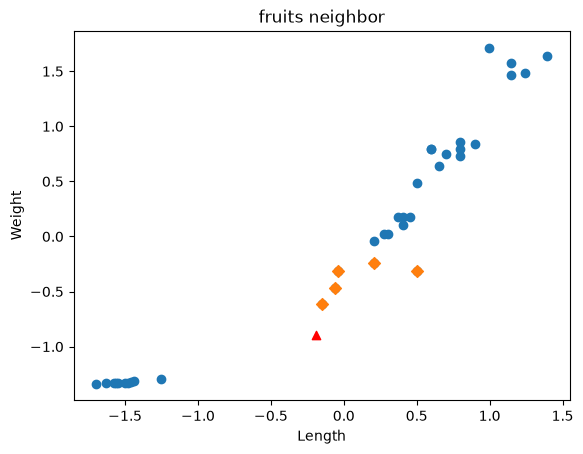

In [99]:
# 이웃의 위치를 출력

distances, indexes = kn.kneighbors([new])
plt.scatter(
   train_scaled3[:,0],
   train_scaled3[:,1]
)

plt.scatter(
   new[0],
   new[1],
   marker="^",
   c="red"
)

plt.scatter(
   train_scaled3[indexes,0],
   train_scaled3[indexes,1],
   marker='D'
)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('fruits neighbor')
plt.show()